   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0      0.0      0.0      5.0     13.0      9.0      1.0      0.0      0.0   
1      0.0      0.0      0.0     12.0     13.0      5.0      0.0      0.0   
2      0.0      0.0      0.0      4.0     15.0     12.0      0.0      0.0   
3      0.0      0.0      7.0     15.0     13.0      1.0      0.0      0.0   
4      0.0      0.0      0.0      1.0     11.0      0.0      0.0      0.0   

   pixel_8  pixel_9  ...  pixel_55  pixel_56  pixel_57  pixel_58  pixel_59  \
0      0.0      0.0  ...       0.0       0.0       0.0       6.0      13.0   
1      0.0      0.0  ...       0.0       0.0       0.0       0.0      11.0   
2      0.0      0.0  ...       0.0       0.0       0.0       0.0       3.0   
3      0.0      8.0  ...       0.0       0.0       0.0       7.0      13.0   
4      0.0      0.0  ...       0.0       0.0       0.0       0.0       2.0   

   pixel_60  pixel_61  pixel_62  pixel_63  label  
0      10.0      

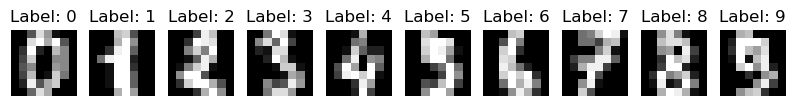

In [3]:
from sklearn.datasets import load_digits
import pandas as pd
import matplotlib.pyplot as plt

# Load the digits dataset
digits = load_digits()

# Features (pixel values)
X = digits.data  

# Labels (the digit: 0–9)
y = digits.target  

# Convert to a pandas DataFrame
df = pd.DataFrame(X, columns=[f'pixel_{i}' for i in range(X.shape[1])])
df['label'] = y

# Print dataset info
print(df.head())
print("Shape of dataset:", X.shape)

# Visualize first 10 handwritten digits
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Label: {digits.target[i]}")
    plt.axis('off')
plt.show()

Accuracy: 0.9622222222222222

Classification Report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        45
           1      0.896     0.935     0.915        46
           2      1.000     0.977     0.989        44
           3      0.979     1.000     0.989        46
           4      0.957     1.000     0.978        45
           5      0.978     0.978     0.978        46
           6      0.978     0.978     0.978        45
           7      1.000     0.978     0.989        45
           8      0.860     0.860     0.860        43
           9      0.976     0.911     0.943        45

    accuracy                          0.962       450
   macro avg      0.962     0.962     0.962       450
weighted avg      0.963     0.962     0.962       450



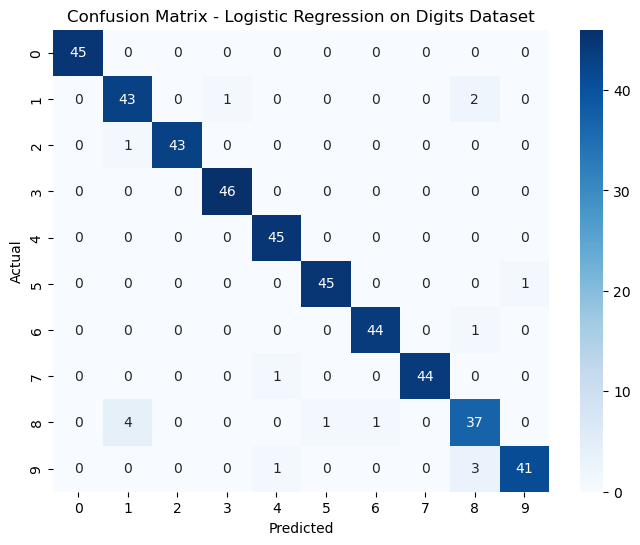

In [4]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
digits = load_digits()
X, y = digits.data, digits.target

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. Train Logistic Regression
log_reg = LogisticRegression(max_iter=5000)  # increase max_iter so it converges
log_reg.fit(X_train, y_train)

# 4. Predictions
y_pred = log_reg.predict(X_test)

# 5. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression on Digits Dataset")
plt.show()

In [5]:
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Prepare table for TP, FP, FN, TN, Precision, Recall, Accuracy
results = []
n_classes = cm.shape[0]
total = cm.sum()

for i in range(n_classes):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = total - (TP + FP + FN)

    # Metrics
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    accuracy = (TP + TN) / total

    results.append([i, TP, FP, FN, TN, precision, recall, accuracy])

# Convert to DataFrame for readability
df_results = pd.DataFrame(results, columns=['Digit', 'TP', 'FP', 'FN', 'TN', 'Precision', 'Recall', 'Accuracy'])

print("Confusion Matrix:\n", cm)
print("\nBreakdown per digit:")
print(df_results.round(3))  # Round for easier reading

Confusion Matrix:
 [[45  0  0  0  0  0  0  0  0  0]
 [ 0 43  0  1  0  0  0  0  2  0]
 [ 0  1 43  0  0  0  0  0  0  0]
 [ 0  0  0 46  0  0  0  0  0  0]
 [ 0  0  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 45  0  0  0  1]
 [ 0  0  0  0  0  0 44  0  1  0]
 [ 0  0  0  0  1  0  0 44  0  0]
 [ 0  4  0  0  0  1  1  0 37  0]
 [ 0  0  0  0  1  0  0  0  3 41]]

Breakdown per digit:
   Digit  TP  FP  FN   TN  Precision  Recall  Accuracy
0      0  45   0   0  405      1.000   1.000     1.000
1      1  43   5   3  399      0.896   0.935     0.982
2      2  43   0   1  406      1.000   0.977     0.998
3      3  46   1   0  403      0.979   1.000     0.998
4      4  45   2   0  403      0.957   1.000     0.996
5      5  45   1   1  403      0.978   0.978     0.996
6      6  44   1   1  404      0.978   0.978     0.996
7      7  44   0   1  405      1.000   0.978     0.998
8      8  37   6   6  401      0.860   0.860     0.973
9      9  41   1   4  404      0.976   0.911     0.989


Random Forest Classifier Results
Accuracy: 0.96

Classification Report:

              precision    recall  f1-score   support

           0      0.977     0.956     0.966        45
           1      0.935     0.935     0.935        46
           2      1.000     0.977     0.989        44
           3      0.939     1.000     0.968        46
           4      0.957     1.000     0.978        45
           5      0.978     0.957     0.967        46
           6      1.000     0.978     0.989        45
           7      0.938     1.000     0.968        45
           8      0.949     0.860     0.902        43
           9      0.933     0.933     0.933        45

    accuracy                          0.960       450
   macro avg      0.961     0.960     0.960       450
weighted avg      0.960     0.960     0.960       450



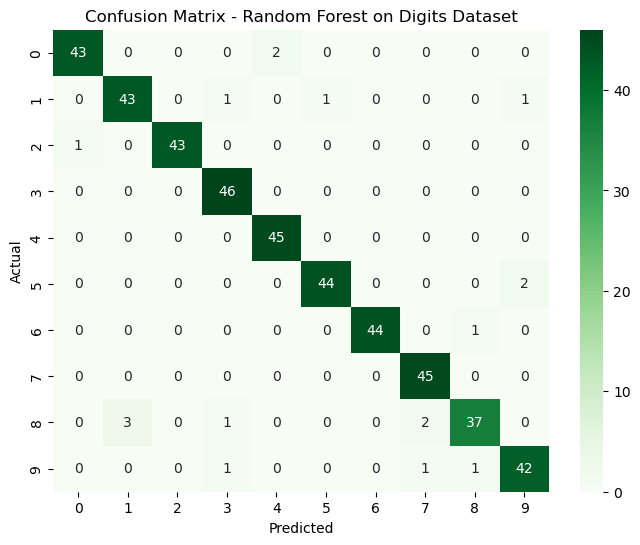

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Cell 4: Random Forest Classifier ---

# Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_clf.predict(X_test)

# Evaluation
print("Random Forest Classifier Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, digits=3))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Greens", xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest on Digits Dataset")
plt.show()

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Prepare summary dictionary
summary = {
    'Classifier': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision (macro)': [
        precision_score(y_test, y_pred, average='macro'),
        precision_score(y_test, y_pred_rf, average='macro')
    ],
    'Recall (macro)': [
        recall_score(y_test, y_pred, average='macro'),
        recall_score(y_test, y_pred_rf, average='macro')
    ],
    'F1-score (macro)': [
        f1_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ]
}

# Convert to DataFrame for readability
df_summary = pd.DataFrame(summary)

print("Comparison of Classifiers:\n")
print(df_summary.round(3))

Comparison of Classifiers:

            Classifier  Accuracy  Precision (macro)  Recall (macro)  \
0  Logistic Regression     0.962              0.962           0.962   
1        Random Forest     0.960              0.961           0.960   

   F1-score (macro)  
0             0.962  
1             0.960  


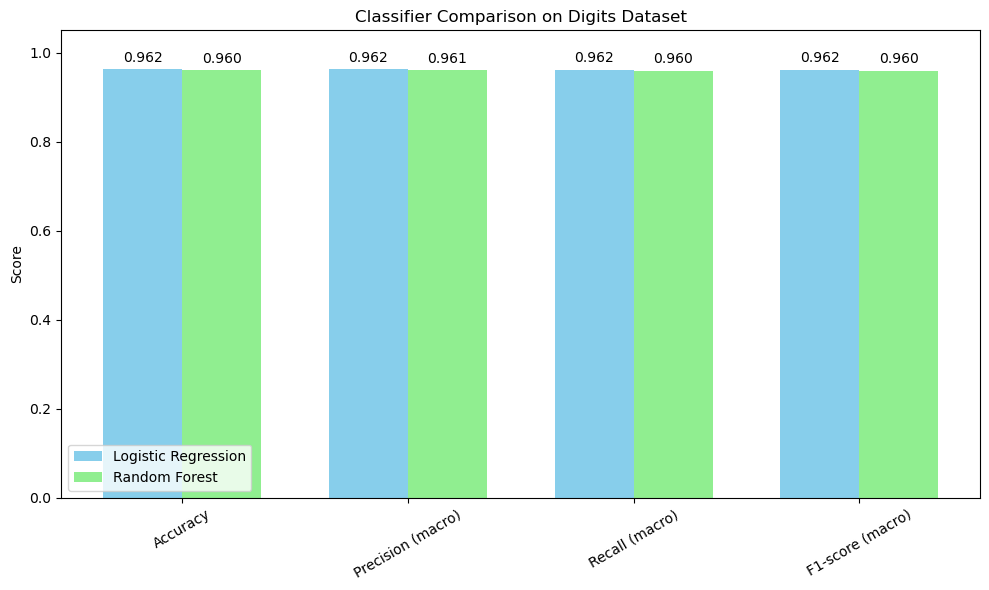

In [8]:
import numpy as np

# Metrics to plot
metrics = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)']

# Values for each classifier
log_values = df_summary.loc[df_summary['Classifier']=='Logistic Regression', metrics].values.flatten()
rf_values = df_summary.loc[df_summary['Classifier']=='Random Forest', metrics].values.flatten()

x = np.arange(len(metrics))  # label locations
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.bar(x - width/2, log_values, width, label='Logistic Regression', color='skyblue')
bars2 = ax.bar(x + width/2, rf_values, width, label='Random Forest', color='lightgreen')

# Labels and title
ax.set_ylabel('Score')
ax.set_title('Classifier Comparison on Digits Dataset')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=30)
ax.set_ylim(0, 1.05)
ax.legend()

# Annotate bars with values
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0,3),  # offset
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import GridSearchCV

# Define base model
log_reg = LogisticRegression(max_iter=5000)

# Define the grid of hyperparameters
param_grid = {
    'C': [0.01, 0.1, 1, 10],              # regularization strength
    'solver': ['lbfgs', 'liblinear'],     # optimization algorithms
    'penalty': ['l2']                     # logistic regression supports l2 with these solvers
}

# Run GridSearchCV
grid = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

# Best results
print("Best Hyperparameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

# Evaluate best model on test set
best_model = grid.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Test Set Accuracy with Best Model:", test_accuracy)

Best Hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.9717775024094726
Test Set Accuracy with Best Model: 0.9622222222222222


Best Hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.9717775024094726


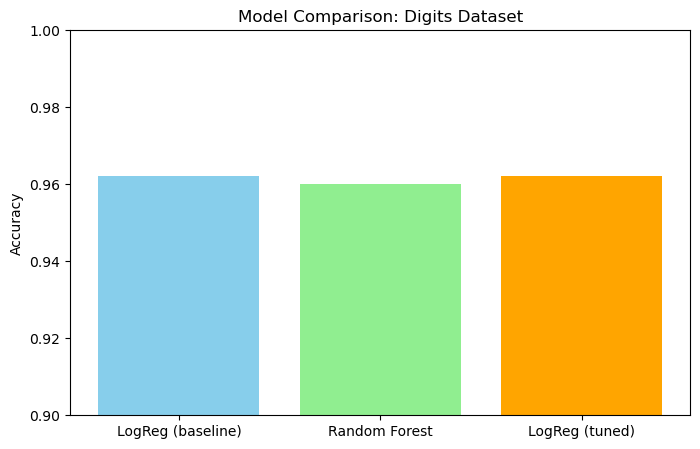

In [13]:
from sklearn.model_selection import GridSearchCV

# --- Logistic Regression (baseline already trained in Cell 2 as log_reg) ---
baseline_acc = accuracy_score(y_test, y_pred)

# --- Random Forest (already trained in Cell 4 as rf_model) ---
rf_acc = accuracy_score(y_test, y_pred_rf)

# --- Logistic Regression with Hyperparameter Tuning ---
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],  # 'l1' requires solver='liblinear', we’ll stick with l2
    'solver': ['lbfgs', 'saga']
}

grid_search = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model after tuning
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
tuned_acc = accuracy_score(y_test, y_pred_best)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# --- Comparison Chart ---
accuracies = {
    "LogReg (baseline)": baseline_acc,
    "Random Forest": rf_acc,
    "LogReg (tuned)": tuned_acc
}

plt.figure(figsize=(8, 5))
plt.bar(accuracies.keys(), accuracies.values(), color=['skyblue', 'lightgreen', 'orange'])
plt.ylabel("Accuracy")
plt.title("Model Comparison: Digits Dataset")
plt.ylim(0.9, 1.0)  # zoom in on high accuracy range
plt.show()